In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_ne_by_design import NE_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx, prox_gaussian

sns.set()

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [3]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [ ]:
def plot_all(model, title):
    xi = np.linspace(-8, 8, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_gaussian(xi), '--', label="soft thr.")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, 0.5 * xi**2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [5]:
def plot_comparison(models):
    xi = np.linspace(-8, 8, 1000)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        axs[0].plot(xi, y, label=name)
        axs[1].plot(xi, c - c.min(), label=name)
        axs[2].plot(xi, p - p.min(), label=name)

    axs[0].plot(xi, prox_gaussian(xi), '--', label="gaussian prox")
    axs[0].set_title("Learned prox")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[2].plot(xi, xi**2 / 2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.suptitle("Model Comparison")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "model_comparison.png"))
    plt.show()
    

In [6]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [7]:
sampler = NormalSampler()
sigma_noise = 1.0
loss_type = 0  # Proximal matching loss
gamma_loss = 0.1
lr_schedule = [1e-3, 1e-4]  # mimic original notebook
iterations_per_phase = 10000

In [8]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [9]:
def get_models():
    return {
        "Original_LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Norm": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Design": NE_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta)
    }

Training Original_LPN...
Original_LPN | Phase 1/2 | Iter 0: Loss = 0.937403
Original_LPN | Phase 1/2 | Iter 100: Loss = 0.895834
Original_LPN | Phase 1/2 | Iter 200: Loss = 0.914492
Original_LPN | Phase 1/2 | Iter 300: Loss = 0.906864
Original_LPN | Phase 1/2 | Iter 400: Loss = 0.894702
Original_LPN | Phase 1/2 | Iter 500: Loss = 0.912057
Original_LPN | Phase 1/2 | Iter 600: Loss = 0.897844
Original_LPN | Phase 1/2 | Iter 700: Loss = 0.897855
Original_LPN | Phase 1/2 | Iter 800: Loss = 0.906391
Original_LPN | Phase 1/2 | Iter 900: Loss = 0.903861
Original_LPN | Phase 1/2 | Iter 1000: Loss = 0.902033
Original_LPN | Phase 1/2 | Iter 1100: Loss = 0.903924
Original_LPN | Phase 1/2 | Iter 1200: Loss = 0.904754
Original_LPN | Phase 1/2 | Iter 1300: Loss = 0.905576
Original_LPN | Phase 1/2 | Iter 1400: Loss = 0.901614
Original_LPN | Phase 1/2 | Iter 1500: Loss = 0.902897
Original_LPN | Phase 1/2 | Iter 1600: Loss = 0.903110
Original_LPN | Phase 1/2 | Iter 1700: Loss = 0.899538
Original_LPN | 

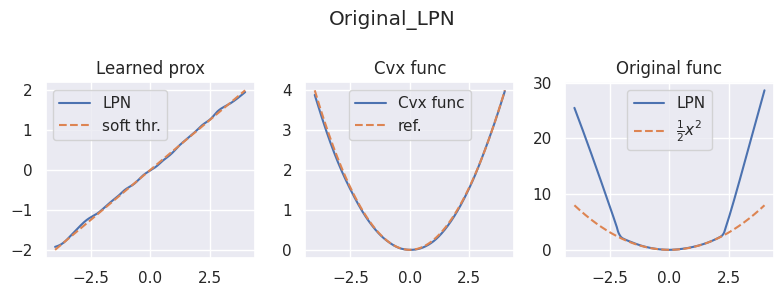

Training NE_By_Norm...
NE_By_Norm | Phase 1/2 | Iter 0: Loss = 0.935141
NE_By_Norm | Phase 1/2 | Iter 100: Loss = 0.907973
NE_By_Norm | Phase 1/2 | Iter 200: Loss = 0.903619
NE_By_Norm | Phase 1/2 | Iter 300: Loss = 0.896614
NE_By_Norm | Phase 1/2 | Iter 400: Loss = 0.904302
NE_By_Norm | Phase 1/2 | Iter 500: Loss = 0.914526
NE_By_Norm | Phase 1/2 | Iter 600: Loss = 0.892501
NE_By_Norm | Phase 1/2 | Iter 700: Loss = 0.895562
NE_By_Norm | Phase 1/2 | Iter 800: Loss = 0.896553
NE_By_Norm | Phase 1/2 | Iter 900: Loss = 0.895726
NE_By_Norm | Phase 1/2 | Iter 1000: Loss = 0.893767
NE_By_Norm | Phase 1/2 | Iter 1100: Loss = 0.898629
NE_By_Norm | Phase 1/2 | Iter 1200: Loss = 0.903949
NE_By_Norm | Phase 1/2 | Iter 1300: Loss = 0.894981
NE_By_Norm | Phase 1/2 | Iter 1400: Loss = 0.892503
NE_By_Norm | Phase 1/2 | Iter 1500: Loss = 0.904506
NE_By_Norm | Phase 1/2 | Iter 1600: Loss = 0.895666
NE_By_Norm | Phase 1/2 | Iter 1700: Loss = 0.900836
NE_By_Norm | Phase 1/2 | Iter 1800: Loss = 0.897454
N

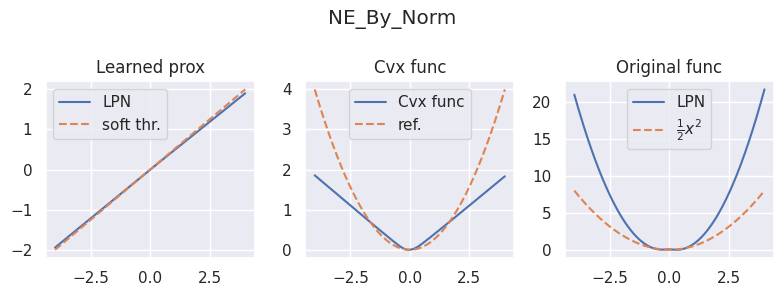

Training NE_By_Design...
NE_By_Design | Phase 1/2 | Iter 0: Loss = 0.937015
NE_By_Design | Phase 1/2 | Iter 100: Loss = 0.943230
NE_By_Design | Phase 1/2 | Iter 200: Loss = 0.934218
NE_By_Design | Phase 1/2 | Iter 300: Loss = 0.918541
NE_By_Design | Phase 1/2 | Iter 400: Loss = 0.908120
NE_By_Design | Phase 1/2 | Iter 500: Loss = 0.909169
NE_By_Design | Phase 1/2 | Iter 600: Loss = 0.905903
NE_By_Design | Phase 1/2 | Iter 700: Loss = 0.903185
NE_By_Design | Phase 1/2 | Iter 800: Loss = 0.909408
NE_By_Design | Phase 1/2 | Iter 900: Loss = 0.906046
NE_By_Design | Phase 1/2 | Iter 1000: Loss = 0.905430
NE_By_Design | Phase 1/2 | Iter 1100: Loss = 0.905004
NE_By_Design | Phase 1/2 | Iter 1200: Loss = 0.891960
NE_By_Design | Phase 1/2 | Iter 1300: Loss = 0.906450
NE_By_Design | Phase 1/2 | Iter 1400: Loss = 0.905296
NE_By_Design | Phase 1/2 | Iter 1500: Loss = 0.910013
NE_By_Design | Phase 1/2 | Iter 1600: Loss = 0.905695
NE_By_Design | Phase 1/2 | Iter 1700: Loss = 0.903934
NE_By_Design | 

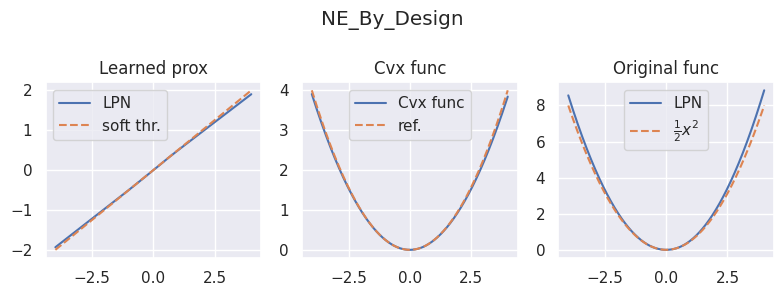

In [10]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

mse 21.376646041870117
mse 17.626575469970703
mse 14.347493171691895
mse 12.044079780578613
mse 9.96454906463623
mse 8.981828689575195
mse 8.784427642822266
mse 8.732218742370605
mse 8.707915306091309
mse 8.69325065612793
mse 8.683067321777344
mse 8.675332069396973
mse 8.669037818908691
mse 8.663562774658203
mse 8.658385276794434
mse 8.652730941772461
mse 8.644124984741211
mse 8.618463516235352
mse 8.58218765258789
mse 8.563858985900879
mse 8.554240226745605
mse 8.548349380493164
mse 8.544260025024414
mse 8.541138648986816
mse 8.538572311401367
mse 8.536334037780762
mse 8.534286499023438
mse 8.532336235046387
mse 8.530420303344727
mse 8.528488159179688
mse 8.526504516601562
mse 8.524449348449707
mse 8.52231502532959
mse 8.520112037658691
mse 8.517863273620605
mse 8.515609741210938
mse 8.51339340209961
mse 8.511247634887695
mse 8.509203910827637
mse 8.507272720336914
mse 8.505461692810059
mse 8.503758430480957
mse 8.502154350280762
mse 8.500631332397461
mse 8.499168395996094
mse 8.49774

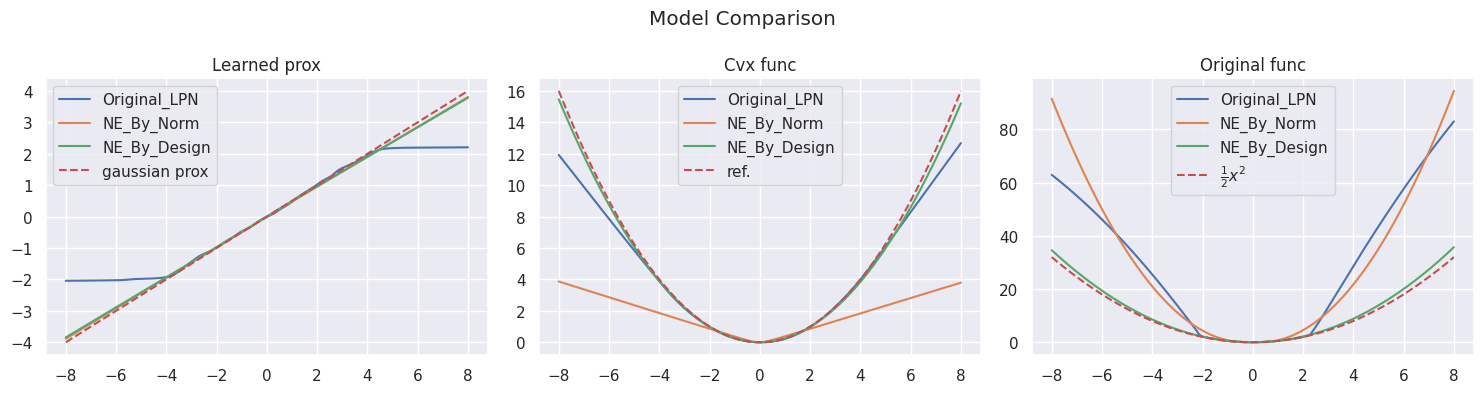

All models trained and plotted.


In [11]:
plot_comparison(trained_models)
print("All models trained and plotted.")

mse 21.378305435180664


mse 17.81513786315918
mse 14.813243865966797
mse 12.282158851623535
mse 10.147156715393066
mse 8.348404884338379
mse 6.836314678192139
mse 5.5690436363220215
mse 4.510898590087891
mse 3.631209373474121
mse 2.903505563735962
mse 2.3048744201660156
mse 1.8154585361480713
mse 1.4180477857589722
mse 1.0977420806884766
mse 0.8416699767112732
mse 0.6387477517127991
mse 0.479471892118454
mse 0.35573670268058777
mse 0.2606734037399292
mse 0.18850521743297577
mse 0.13441519439220428
mse 0.0944269448518753
mse 0.06529419869184494
mse 0.044399239122867584
mse 0.029660092666745186
mse 0.01944568380713463
mse 0.012498716823756695
mse 0.007867139764130116
mse 0.004843663424253464
mse 0.0029134689830243587
mse 0.0017099204706028104
mse 0.0009778961539268494
mse 0.000544195412658155
mse 0.0002942529390566051
mse 0.00015435546811204404
mse 7.842341437935829e-05
mse 3.8525213312823325e-05
mse 1.8264994650962763e-05
mse 8.341265129274689e-06
mse 3.661900109364069e-06
mse 1.5420234831253765e-06
mse 6.2149

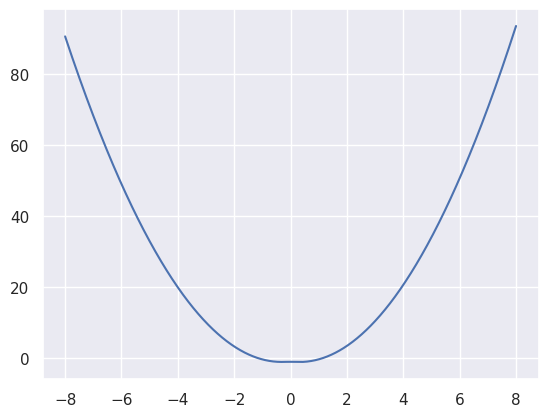

In [12]:
xi = np.linspace(-8, 8, 1000)
pi = prior(xi, trained_models["NE_By_Norm"])
print("prior shape: ", pi.shape)
plt.plot(xi, pi, label="Learned Prior")